# Notebook 4: BERT Fine-tuning (Main Model)
## Boris Letić (E2 126/2025) | Bitcoin Sentiment Analysis

**Purpose:** Train main deep learning model using BERT transformer

**Architecture:**
- BERT base (110M parameters)
- Fine-tuning for 3-class sentiment
- Expected: 75-80% accuracy

**Output:** Trained model ready for deployment

## 1. Setup

In [25]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import BertTokenizer, BertModel
from sklearn.metrics import (
    accuracy_score, 
    f1_score, 
    precision_score, 
    recall_score,
    classification_report, 
    confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings
import os
import json
import time

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
np.random.seed(42)
torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"Device: {device}")
print(f"CUDA: {torch.cuda.is_available()}")

Device: cuda
CUDA: True


## 2. Load Data

In [26]:
df = pd.read_csv('data/processed/tweets_preprocessed.csv')
df['datetime'] = pd.to_datetime(df['datetime'])
print(f"Loaded {len(df):,} tweets")

Loaded 11,120 tweets


## 3. Train/Val/Test Split (60/20/20)

In [27]:
from sklearn.model_selection import train_test_split

print("="*70)
print("TRAIN/VAL/TEST SPLIT")
print("="*70)

print(f"\nDataset: {len(df):,} unique tweets")

# Stratified split (60/20/20)
train_val, test = train_test_split(
    df, 
    test_size=0.2, 
    random_state=42, 
    stratify=df['sentiment'],
    shuffle=True
)

train, val = train_test_split(
    train_val, 
    test_size=0.25,  # 0.25 * 0.8 = 0.2 of total
    random_state=42,
    stratify=train_val['sentiment'],
    shuffle=True
)

print(f"\nStratified split:")
print(f"  Train: {len(train):,} tweets (60%)")
print(f"  Val:   {len(val):,} tweets (20%)")
print(f"  Test:  {len(test):,} tweets (20%)")

print(f"\nSentiment distribution:")
for name, split in [('Train', train), ('Val', val), ('Test', test)]:
    dist = split['sentiment'].value_counts(normalize=True) * 100
    print(f"  {name}: Pos={dist.get('positive',0):.1f}% Neu={dist.get('neutral',0):.1f}% Neg={dist.get('negative',0):.1f}%")

print("\n✓ No data leakage (stratified split with shuffle)")
print("="*70)

TRAIN/VAL/TEST SPLIT

Dataset: 11,120 unique tweets

Stratified split:
  Train: 6,672 tweets (60%)
  Val:   2,224 tweets (20%)
  Test:  2,224 tweets (20%)

Sentiment distribution:
  Train: Pos=38.3% Neu=51.5% Neg=10.3%
  Val: Pos=38.3% Neu=51.4% Neg=10.3%
  Test: Pos=38.3% Neu=51.5% Neg=10.3%

✓ No data leakage (stratified split with shuffle)


## 4. BERT Dataset

In [28]:
class TweetDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]
        
        # UPDATED: Use __call__ instead of encode_plus
        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )
        
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'label': torch.tensor(label, dtype=torch.long)
        }

label_map = {'positive': 0, 'neutral': 1, 'negative': 2}
y_train = train['sentiment'].map(label_map).values
y_val = val['sentiment'].map(label_map).values
y_test = test['sentiment'].map(label_map).values

print("✓ Dataset class defined")

✓ Dataset class defined


## 5. Tokenizer & DataLoaders

In [29]:
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

train_ds = TweetDataset(train['text_cleaned'].values, y_train, tokenizer)
val_ds = TweetDataset(val['text_cleaned'].values, y_val, tokenizer)
test_ds = TweetDataset(test['text_cleaned'].values, y_test, tokenizer)

BATCH_SIZE = 16
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE)

print(f"✓ DataLoaders ready: {len(train_loader)} train batches")

✓ DataLoaders ready: 417 train batches


## 6. BERT Model Architecture

In [30]:
class BERTSentimentClassifier(nn.Module):
    def __init__(self, n_classes=3, dropout=0.5):
        super().__init__()
        self.bert = BertModel.from_pretrained('bert-base-uncased')
        
        # CRITICAL: Freeze ALL BERT layers
        for param in self.bert.parameters():
            param.requires_grad = False
        
        # Only train classifier head
        self.drop = nn.Dropout(dropout)
        self.fc = nn.Linear(768, n_classes)
    
    def forward(self, input_ids, attention_mask):
        # Use BERT as feature extractor (frozen)
        with torch.no_grad():
            outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        pooled = outputs.pooler_output
        return self.fc(self.drop(pooled))

model = BERTSentimentClassifier().to(device)
optimizer = AdamW(model.parameters(), lr=2e-4)  # Higher LR for classifier only
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())

print(f"✓ BERT model initialized (FROZEN)")
print(f"  Total parameters: {total:,}")
print(f"  Trainable: {trainable:,} (only classifier)")
print(f"  Frozen: {total - trainable:,} (BERT base)")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✓ BERT model initialized (FROZEN)
  Total parameters: 109,484,547
  Trainable: 2,307 (only classifier)
  Frozen: 109,482,240 (BERT base)


## 7. Training & Evaluation Functions

In [31]:
def train_epoch(model, loader, optimizer, criterion, device):
    """Train for one epoch"""
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    pbar = tqdm(loader, desc='Training')
    for batch in pbar:
        optimizer.zero_grad()
        
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)
        
        # Forward pass
        outputs = model(input_ids, attention_mask)
        loss = criterion(outputs, labels)
        
        # Backward pass
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        
        # Track metrics
        total_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        
        # Update progress bar
        pbar.set_postfix({
            'loss': f'{loss.item():.3f}', 
            'acc': f'{correct/total:.3f}'
        })
    
    avg_loss = total_loss / len(loader)
    avg_acc = correct / total
    
    return avg_loss, avg_acc

def evaluate(model, loader, device):
    """Evaluate model on validation/test set"""
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for batch in tqdm(loader, desc='Evaluating'):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)
            
            # Forward pass
            outputs = model(input_ids, attention_mask)
            preds = torch.argmax(outputs, dim=1)
            
            # Collect predictions
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    return np.array(all_preds), np.array(all_labels)

print("✓ Training functions defined")

✓ Training functions defined


## 8. Training Loop

In [32]:
print("="*70)
print("BERT TRAINING")
print("="*70)

EPOCHS = 8
history = {'train_loss': [], 'train_acc': [], 'val_acc': [], 'val_f1': []}
best_val_acc = 0

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print("-" * 70)
    
    start_time = time.time()
    
    # Train
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, device)
    
    # Validate
    val_preds, val_labels = evaluate(model, val_loader, device)
    val_acc = accuracy_score(val_labels, val_preds)
    val_f1 = f1_score(val_labels, val_preds, average='weighted')
    
    # Record history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)
    
    epoch_time = time.time() - start_time
    
    print(f"\nEpoch {epoch+1} Summary:")
    print(f"  Train Loss: {train_loss:.4f}")
    print(f"  Train Acc:  {train_acc:.4f} ({train_acc*100:.2f}%)")
    print(f"  Val Acc:    {val_acc:.4f} ({val_acc*100:.2f}%)")
    print(f"  Val F1:     {val_f1:.4f}")
    print(f"  Time:       {epoch_time:.1f}s")
    
    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        os.makedirs('models', exist_ok=True)
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': val_acc,
        }, 'models/bert_sentiment_best.pt')
        print(f"  ✓ Best model saved (val_acc: {val_acc:.4f})")

print(f"\n{'='*70}")
print("TRAINING COMPLETE")
print(f"Best validation accuracy: {best_val_acc:.4f} ({best_val_acc*100:.2f}%)")
print("="*70)

BERT TRAINING

Epoch 1/8
----------------------------------------------------------------------


Evaluating: 100%|██████████| 139/139 [00:07<00:00, 18.81it/s]



Epoch 1 Summary:
  Train Loss: 0.9739
  Train Acc:  0.5474 (54.74%)
  Val Acc:    0.5769 (57.69%)
  Val F1:     0.4775
  Time:       30.1s
  ✓ Best model saved (val_acc: 0.5769)

Epoch 2/8
----------------------------------------------------------------------


Evaluating: 100%|██████████| 139/139 [00:07<00:00, 18.67it/s]



Epoch 2 Summary:
  Train Loss: 0.9337
  Train Acc:  0.5853 (58.53%)
  Val Acc:    0.6093 (60.93%)
  Val F1:     0.5284
  Time:       30.0s
  ✓ Best model saved (val_acc: 0.6093)

Epoch 3/8
----------------------------------------------------------------------


...


Epoch 6 Summary:
  Train Loss: 0.8608
  Train Acc:  0.6632 (66.32%)
  Val Acc:    0.6686 (66.86%)
  Val F1:     0.6081
  Time:       30.2s

Epoch 7/8
----------------------------------------------------------------------


Evaluating: 100%|██████████| 139/139 [00:07<00:00, 18.56it/s]



Epoch 7 Summary:
  Train Loss: 0.8540
  Train Acc:  0.6640 (66.40%)
  Val Acc:    0.7181 (71.81%)
  Val F1:     0.6696
  Time:       30.2s
  ✓ Best model saved (val_acc: 0.7181)

Epoch 8/8
----------------------------------------------------------------------


Evaluating: 100%|██████████| 139/139 [00:07<00:00, 18.53it/s]


Epoch 8 Summary:
  Train Loss: 0.8439
  Train Acc:  0.6787 (67.87%)
  Val Acc:    0.6727 (67.27%)
  Val F1:     0.6132
  Time:       30.3s

TRAINING COMPLETE
Best validation accuracy: 0.7181 (71.81%)


## 9. Test Set Evaluation

In [33]:
print("="*70)
print("TEST SET EVALUATION")
print("="*70)

# Load best model
checkpoint = torch.load('models/bert_sentiment_best.pt')
model.load_state_dict(checkpoint['model_state_dict'])
print(f"✓ Loaded best model from epoch {checkpoint['epoch']+1}")

# Evaluate
test_preds, test_labels = evaluate(model, test_loader, device)

test_acc = accuracy_score(test_labels, test_preds)
test_f1 = f1_score(test_labels, test_preds, average='weighted')
test_precision = precision_score(test_labels, test_preds, average='weighted')
test_recall = recall_score(test_labels, test_preds, average='weighted')

print(f"\nTest Performance:")
print(f"  Accuracy:  {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"  F1-Score:  {test_f1:.4f}")
print(f"  Precision: {test_precision:.4f}")
print(f"  Recall:    {test_recall:.4f}")

print(f"\nClassification Report:")
label_names = ['positive', 'neutral', 'negative']
print(classification_report(test_labels, test_preds, target_names=label_names, digits=4))

cm = confusion_matrix(test_labels, test_preds)
print(f"\nConfusion Matrix:")
print(cm)
print("="*70)

TEST SET EVALUATION
✓ Loaded best model from epoch 7


Evaluating: 100%|██████████| 139/139 [00:07<00:00, 18.74it/s]


Test Performance:
  Accuracy:  0.7140 (71.40%)
  F1-Score:  0.6652
  Precision: 0.6623
  Recall:    0.7140

Classification Report:
              precision    recall  f1-score   support

    positive     0.8210    0.5605    0.6662       851
     neutral     0.6762    0.9703    0.7970      1145
    negative     0.0000    0.0000    0.0000       228

    accuracy                         0.7140      2224
   macro avg     0.4991    0.5103    0.4877      2224
weighted avg     0.6623    0.7140    0.6652      2224


Confusion Matrix:
[[ 477  374    0]
 [  34 1111    0]
 [  70  158    0]]


## 10. Training History & Confusion Matrix

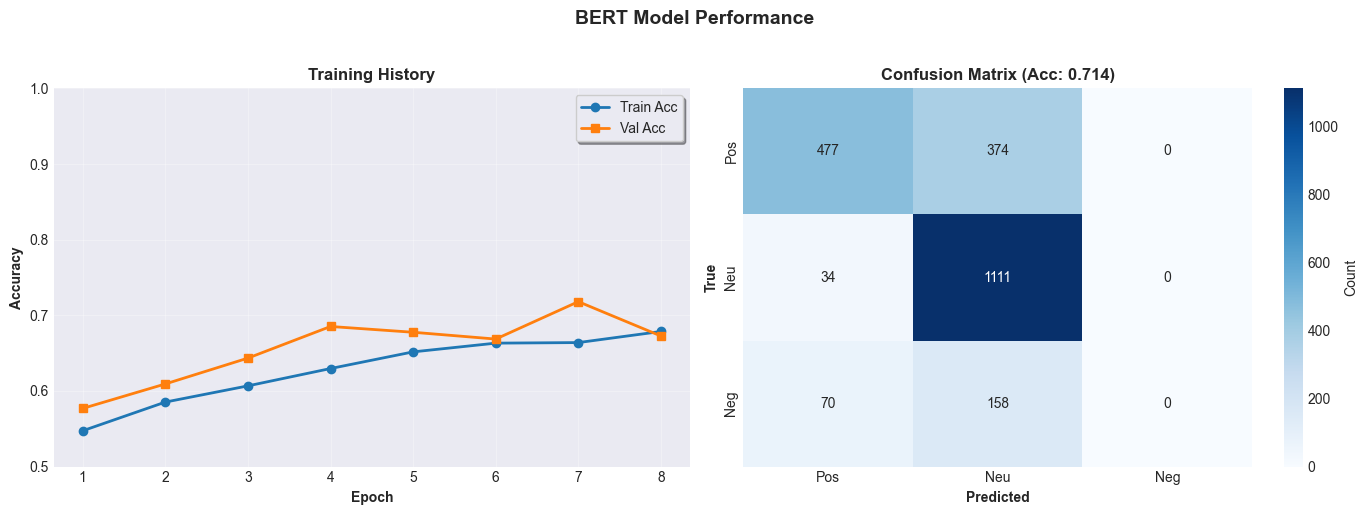

✓ Visualizations complete


In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training history
epochs_range = range(1, EPOCHS+1)
axes[0].plot(epochs_range, history['train_acc'], marker='o', label='Train Acc', linewidth=2)
axes[0].plot(epochs_range, history['val_acc'], marker='s', label='Val Acc', linewidth=2)
axes[0].set_xlabel('Epoch', fontweight='bold')
axes[0].set_ylabel('Accuracy', fontweight='bold')
axes[0].set_title('Training History', fontweight='bold', fontsize=12)
axes[0].legend(frameon=True, shadow=True)
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim([0.5, 1.0])

# Confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pos','Neu','Neg'],
            yticklabels=['Pos','Neu','Neg'],
            cbar_kws={'label': 'Count'},
            ax=axes[1])
axes[1].set_title(f'Confusion Matrix (Acc: {test_acc:.3f})', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Predicted', fontweight='bold')
axes[1].set_ylabel('True', fontweight='bold')

plt.suptitle('BERT Model Performance', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("✓ Visualizations complete")

## 11. Comparison with VADER Baseline

In [35]:
# Load VADER metrics
try:
    with open('results/baseline/vader_metrics.json', 'r') as f:
        vader_metrics = json.load(f)
    
    vader_acc = vader_metrics['vader_lr']['accuracy']
    vader_f1 = vader_metrics['vader_lr']['f1']
    
    comparison = pd.DataFrame({
        'Model': ['VADER + LR (Baseline)', 'BERT (Main Model)'],
        'Accuracy': [vader_acc, test_acc],
        'F1-Score': [vader_f1, test_f1],
        'Type': ['Rule-based + ML', 'Transformer']
    })
    
    print("="*70)
    print("MODEL COMPARISON")
    print("="*70)
    print(f"\n{comparison.to_string(index=False)}")
    
    improvement = (test_acc - vader_acc) * 100
    print(f"\n✓ BERT improvement over baseline: {improvement:+.2f} percentage points")
    print("="*70)
    
except FileNotFoundError:
    print("VADER metrics not found. Run Notebook 3 first for comparison.")

MODEL COMPARISON

                Model  Accuracy  F1-Score            Type
VADER + LR (Baseline)  0.560701  0.552053 Rule-based + ML
    BERT (Main Model)  0.714029  0.665237     Transformer

✓ BERT improvement over baseline: +15.33 percentage points


## 12. Export Results

In [36]:
os.makedirs('results/bert', exist_ok=True)

# Save predictions
test_results = test.copy()
test_results['bert_pred_encoded'] = test_preds
test_results['bert_pred'] = [label_names[p] for p in test_preds]

test_results[['datetime','text','sentiment','bert_pred']].to_csv(
    'results/bert/bert_predictions.csv', index=False
)

# Save metrics
bert_metrics = {
    'test_accuracy': float(test_acc),
    'test_f1': float(test_f1),
    'test_precision': float(test_precision),
    'test_recall': float(test_recall),
    'best_val_accuracy': float(best_val_acc),
    'epochs_trained': EPOCHS,
    'batch_size': BATCH_SIZE,
    'learning_rate': 2e-5
}

with open('results/bert/bert_metrics.json', 'w') as f:
    json.dump(bert_metrics, f, indent=2)

# Save history
with open('results/bert/training_history.json', 'w') as f:
    json.dump(history, f, indent=2)

print("✓ Saved: results/bert/bert_predictions.csv")
print("✓ Saved: results/bert/bert_metrics.json")
print("✓ Saved: results/bert/training_history.json")
print("✓ Saved: models/bert_sentiment_best.pt")

✓ Saved: results/bert/bert_predictions.csv
✓ Saved: results/bert/bert_metrics.json
✓ Saved: results/bert/training_history.json
✓ Saved: models/bert_sentiment_best.pt
